## Image of a Single Perceptron

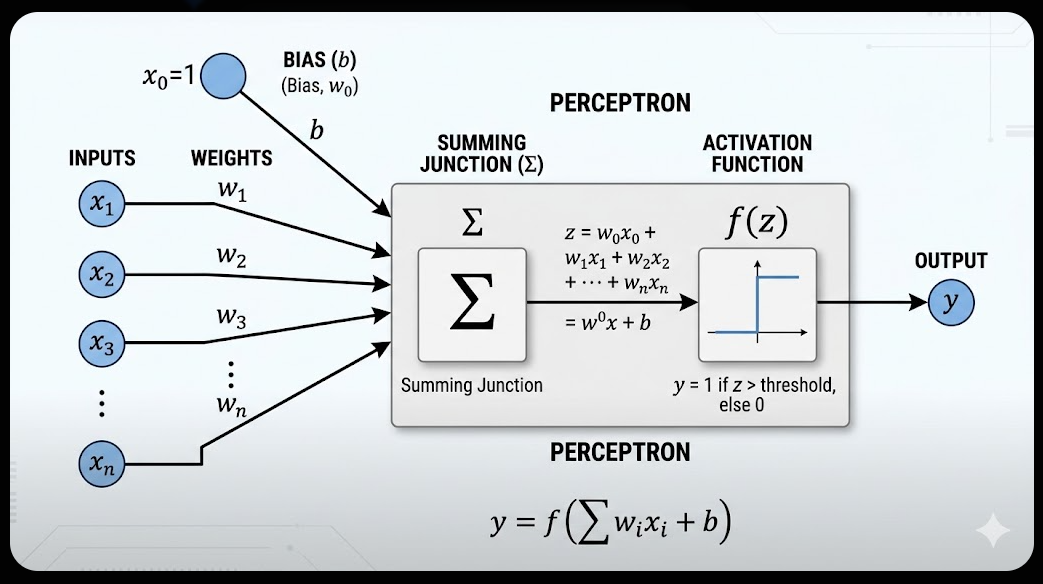

## Image of Multi Layer Perceptron

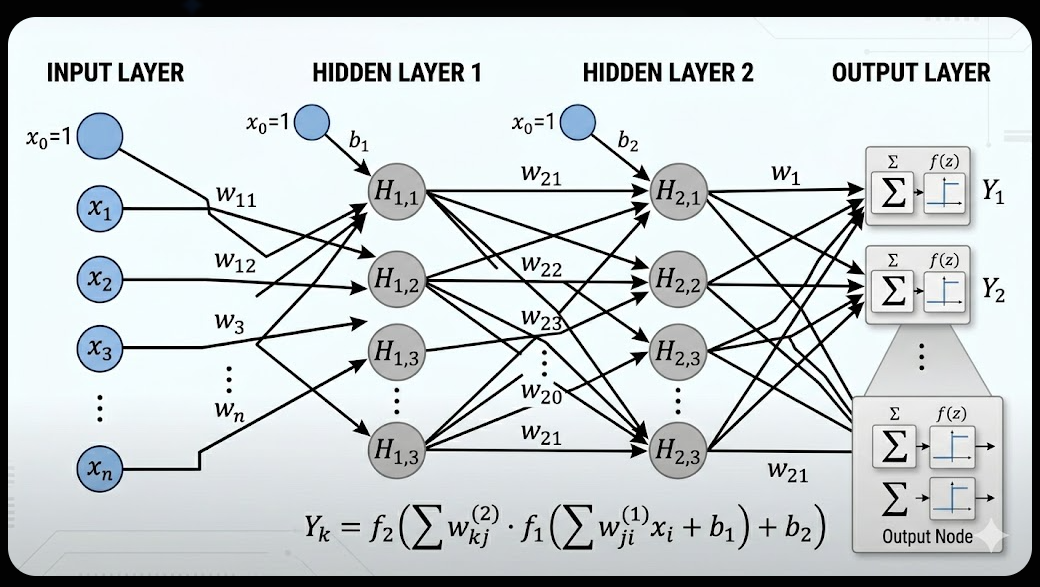

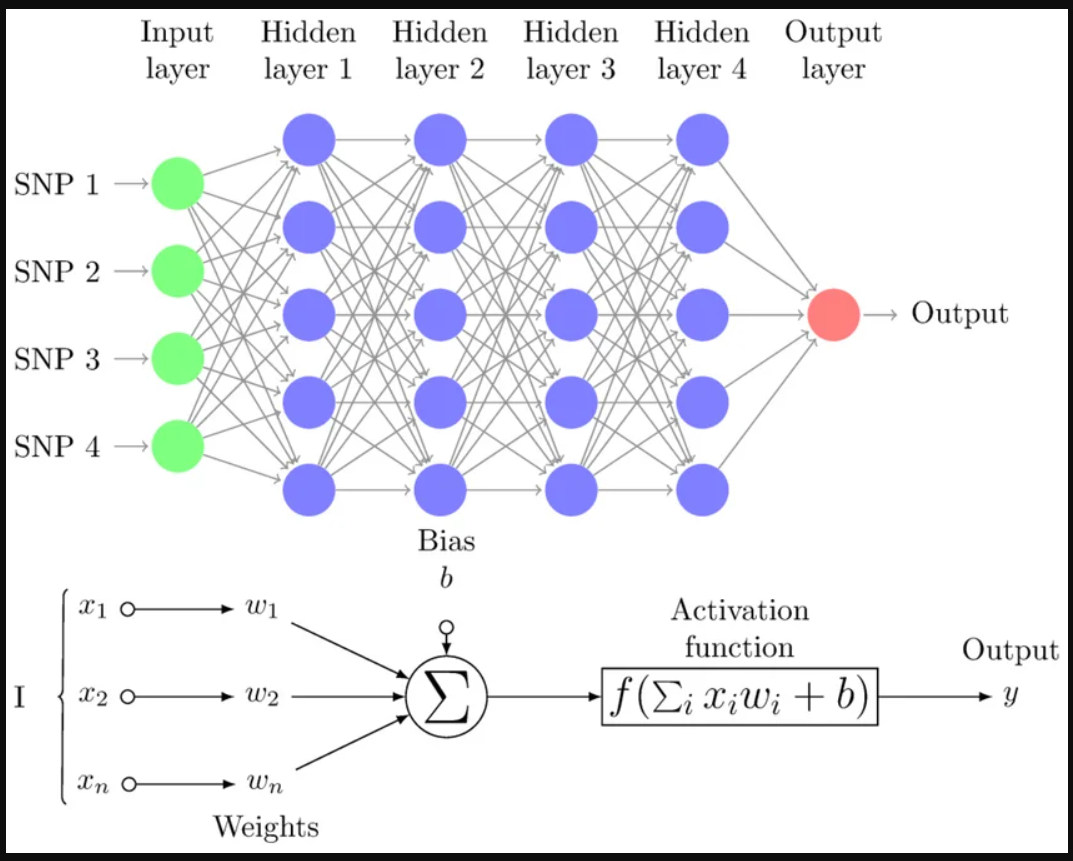

# Deep Learning Fundamentals: The Perceptron



## 1. What is a Perceptron?
A **Perceptron** is the fundamental building block of an Artificial Neural Network. It is a biological neuron-inspired algorithm used for supervised learning of binary classifiers. 

It processes input data by:
1.  Multiplying each input ($x$) by a specific weight ($w$).
2.  Adding a **Bias** ($b$) to the sum.
3.  Passing the result through an **Activation Function** (typically a Step Function) to determine the output (0 or 1).





## 2. Single-Layer vs. Multi-Layer Perceptron (MLP)

| Feature | Single-Layer Perceptron | Multi-Layer Perceptron (MLP) |
| :--- | :--- | :--- |
| **Architecture** | Only one layer of output nodes. | Includes Input, Output, and one or more **Hidden Layers**. |
| **Linearity** | Can only learn **Linearly Separable** patterns. | Can learn **Non-linear** and complex patterns. |
| **Activation** | Usually uses a Step Function. | Uses non-linear functions like ReLU, Sigmoid, or Tanh. |
| **Training** | Simple weight adjustment based on error. | Uses **Backpropagation** to update weights across layers. |



## 3. Pros and Cons: Single-Layer Perceptron

### **Pros**
*   **Simplicity:** Extremely easy to implement and computationally inexpensive.
*   **Efficiency:** Converges very quickly if the data is linearly separable.
*   **Foundational:** Excellent for understanding the basics of how neural weight updates work.

### **Cons**
*   **The "XOR" Problem:** It cannot solve problems where data isn't separable by a straight line [doesnot follow a linear pattern] (e.g., the XOR gate).
*   **Limited Scope:** Cannot handle complex datasets like images or natural language.
*   **Binary Only:** Historically limited to binary classification (0 or 1).



## 4. Pros and Cons: Multi-Layer Perceptron (MLP)

### **Pros**
*   **Universal Approximator:** In theory, an MLP with enough hidden neurons can represent any continuous function [can also work with non-linear data].
*   **Complex Feature Extraction:** Can identify intricate relationships in high-dimensional data.
*   **Versatility:** Used in a wide range of tasks from stock price prediction to basic image recognition.

### **Cons**
*   **Computational Cost:** Requires more memory and processing power as hidden layers increase.
*   **Overfitting:** Risk of memorizing training data rather than generalizing, especially with small datasets.
*   **Black Box Nature:** It is often difficult to interpret *why* an MLP reached a specific decision compared to a single perceptron.



## 5. General Pros and Cons of Using Perceptrons in DL

### **Pros**
1.  **Modularity:** Perceptrons can be stacked in infinite ways to create modern architectures like CNNs and RNNs.
2.  **Scalability:** They form the basis of "Deep" learning; adding more layers allows for deeper abstraction.
3.  **Real-time Prediction:** Once trained, the forward pass of a perceptron is nearly instantaneous.

### **Cons**
1.  **Vanishing Gradients:** In very deep MLPs, the error signal can become so small that the early layers stop learning.
2.  **Hyperparameter Sensitivity:** Performance relies heavily on choosing the right learning rate, activation function, and number of layers.
3.  **Data Hungry:** Perceptron-based models generally require large amounts of labeled data to outperform traditional statistical methods. 
4.  **Cannot find the best dividing hyperplane**: The Perceptron Trick does not provide a way to measure how good or how bad the resulting classification is. You cannot quantify if  the line found is truly the "best" possible line to separate the data classes. Consequently, you cannot be certain if a better solution exists elsewhere.
    - In simple terms if there are two hyper planes dividing two classes perfectly, the model will not be able to detect, which hyperplane is best suited for the model.
5.  **Non-Uniqueness of the Solution**: Since the algorithm relies on randomly selecting points to adjust the line, you might get different lines (and different weights/biases) every time you run it. There is no mechanism to guarantee you have reached the optimal configuration.
6.  **Potential Convergence Issues**: While it works in 98% of cases, there is no absolute guarantee of convergence. It is theoretically possible to encounter scenarios where the algorithm fails to converge or gets stuck, especially if the random selection process does not effectively guide the line toward the optimal position.

---
---


# The Mathematical Bridge: Linear Regression to Perceptron



## 1. The Shared "Core" Equation
At their heart, Linear Regression, Logistic Regression, and the Perceptron all rely on the same linear combination of inputs and weights.

$$z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

In code, when you call `p.coef_` and `p.intercept_`, you are looking at these $w$ (weights) and $b$ (bias) values.



## 2. Evolution of the Output
The difference lies entirely in what happens to $z$ after it is calculated.

### **Linear Regression (The Basis)**
*   **Transformation:** None.
*   **Output:** $\hat{y} = z$
*   **Nature:** Continuous. If $z$ is 15.7, the prediction is 15.7.

### **Logistic Regression (The "Soft" Threshold)**
*   **Transformation:** The **Sigmoid Function**.
*   **Output:** $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$
*   **Nature:** Probability. It returns a value between 0 and 1 (e.g., 0.85). You then apply a threshold (usually 0.5) to classify.

### **Perceptron (The "Hard" Threshold)**
*   **Transformation:** The **Heaviside Step Function**.
*   **Output:** 
    *   $\hat{y} = 1$ if $z > 0$
    *   $\hat{y} = 0$ if $z \leq 0$
*   **Nature:** Binary. It jumps instantly from 0 to 1 at the threshold.



## 3. Comparison Table: Math & Logic

| Feature | Linear Regression | Logistic Regression | Single Perceptron |
| :--- | :--- | :--- | :--- |
| **Output Type** | Continuous value | Probability (0 to 1) | Class Label (0 or 1) |
| **Activation** | Identity (None) | Sigmoid | Step Function |
| **Loss Function** | Mean Squared Error | Log Loss (Cross-Entropy) | Perceptron Loss |
| **Boundary** | Fits a line to data | Separates classes | Separates classes |



## 4. Visualizing the Thresholds



### **Hard vs. Soft Thresholding**
*   **Perceptron (Hard):** Like a light switch. It is either ON or OFF. There is no concept of "confidence." If a data point is barely across the line or miles across the line, the Perceptron treats them exactly the same.
*   **Logistic Regression (Soft):** Like a dimmer switch. It tells you *how likely* a point is to belong to a class. Points far from the boundary have probabilities near 1.0 or 0.0, while points near the boundary are near 0.5.



## 5. Summary for the Coder
When you use `sklearn.linear_model.Perceptron`:
1.  It finds the `coef_` ($w$) and `intercept_` ($b$) that define a **line**.
2.  It uses that line as a fence: everything on one side is Class A, everything on the other is Class B.
3.  Unlike Linear Regression, it doesn't care about the *distance* from the line, only which *side* the point is on.

---
---

### The Full Mathematics of the Perceptron

The Perceptron algorithm is built on three core mathematical formulas: the Prediction Function, the Loss Function, and the Weight Update Rule.

#### 1. The Prediction Function (Hypothesis)
To make a prediction, the Perceptron calculates the dot product of the input features ($\mathbf{x}$) and the weights ($\mathbf{w}$), adds the bias ($b$), and passes the result ($z$) through a Step Function:

$$ z = \mathbf{w} \cdot \mathbf{x} + b $$

$$ \hat{y} = \begin{cases} 
      +1 & \text{if } z \geq 0 \\
      -1 & \text{if } z < 0 
   \end{cases} $$
*Where $\hat{y}$ is the predicted class label.*

#### 2. The Perceptron Loss Function (Perceptron Criterion)
The Loss Function calculates the error for a single data point $i$. By using the `max` function, it acts as an "ignore switch," returning exactly $0$ if the prediction is correct, and returning a positive penalty number if the prediction is wrong:

$$ L_i(\mathbf{w}, b) = \max(0, -y_i (\mathbf{w} \cdot \mathbf{x}_i + b)) $$

To calculate the **Total Loss** (or Cost) over the entire dataset of $N$ samples, we calculate the average of all individual errors:

$$ J(\mathbf{w}, b) = \frac{1}{N} \sum_{i=1}^{N} \max(0, -y_i (\mathbf{w} \cdot \mathbf{x}_i + b)) $$
*Where $y_i$ is the True Label.*

#### 3. The Weight Update Rule (Stochastic Gradient Descent)
The algorithm loops through the data. If a point is misclassified (meaning the Loss is $> 0$), the Perceptron updates its weights and bias to "tilt" the line in the correct direction. It uses a Learning Rate ($\eta$) to control how big the adjustment is:

$$ \mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} + \eta (y_i - \hat{y}_i) \mathbf{x}_i $$

$$ b_{\text{new}} = b_{\text{old}} + \eta (y_i - \hat{y}_i) $$

*Note: If the prediction is correct ($y_i = \hat{y}_i$), the math becomes $\eta(0)\mathbf{x}_i$, meaning the weights do not change!*


### Understanding the Perceptron Loss Function

In the Perceptron algorithm, we **do not** use **Euclidean Distance**. Euclidean Distance is utilized in distance-based algorithms like K-Nearest Neighbors (KNN) to measure the physical similarity between data points. 

The Perceptron, however, is a linear classifier. It does not care about the distance between points; it only cares about drawing a straight line (a hyperplane) to separate classes. Therefore, it uses a specialized loss function known as the **Perceptron Criterion** (a simplified version of **Hinge Loss**).

#### 1. What is the Perceptron Loss Function?
The mathematical formula for the Perceptron Loss for a single data point is:
$$ L = \max(0, -y_i (\mathbf{w} \cdot \mathbf{x}_i + b)) $$

*   $\mathbf{w} \cdot \mathbf{x}_i + b$: This is the raw output of our linear equation (the dot product of weights and inputs, plus the bias).
*   $y_i$: This is the actual true label of the data point (represented as $+1$ or $-1$).
*   We use the $\max(0, \dots)$ function because it acts as an "ignore switch" (or a mathematical floor) to prevent the concept of "negative loss".
    * whenever the value is less than 0, it will compare btwn 0 and negayive value and will take the erros as 0. This is bcoz, when you get error in -ve numbers, that means there is no error in the predicted value.

Think about how loss functions work: Loss represents how many mistakes the model is making.

If the model makes a mistake, we want the loss to be a positive number (e.g., a loss of 5).
If the model gets it perfectly right, we want the loss to be exactly 0.
We never want the loss to be negative.

#### Without max(0)
- Let's pretend we removed the max and just used the inside math: $L = -y_i (\mathbf{w} \cdot \mathbf{x}_i + b)$

- If a data point is extremely far on the correct side of the boundary line, the formula might calculate the loss as -100. If the model sees a loss of -100, it thinks: "Wow, a negative loss is even better than 0! I should keep pushing the line further and further to make this loss even more negative!" This breaks the model, because the Perceptron would obsess over points it already got correct instead of fixing its mistakes.

#### 2. How Does it Work?
The primary rule of the Perceptron Loss function is that it **only penalizes misclassified points**.

*   **Scenario A (Correct Classification):** If the model predicts correctly, the sign of the prediction matches the true label ($+$ and $+$, or $-$ and $-$). Multiplying them results in a positive number. Because of the negative sign in the formula, it evaluates to $\max(0, \text{negative number})$, which equals **0**. *The loss is zero, and the model ignores the point.*
*   **Scenario B (Incorrect Classification):** If the model is wrong, the signs do not match. Multiplying them results in a negative number. The double negative makes it positive, evaluating to $\max(0, \text{positive number})$. *The loss is greater than zero, which triggers the algorithm to update its weights to fix the mistake.*

#### 3. Why avoid Euclidean Distance?
Euclidean distance calculates the literal "ruler distance" between two coordinates ($d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$). 

If we used Euclidean distance, the model would try to group points that are physically close together. But a Perceptron's job isn't grouping—it is finding a mathematical boundary. The Perceptron Criterion is vastly superior here because it specifically calculates **"how far on the wrong side of the boundary line is this point?"** enabling it to aggressively push the line until the classes are separated.


# IMPORTANT

### How the Perceptron Loss Formula Works
A common point of confusion is how the math inside the $\max()$ function actually calculates the error. To understand it, we must separate the **Prediction Score** from the **Final Error**.

**The Terms:**
1. **Prediction Score ($z$):** The raw output of the linear equation ($z = \mathbf{w} \cdot \mathbf{x} + b$). It represents how far the point is from the boundary line. (e.g., $+5$ means it is 5 steps on the positive side of the line).
2. **True Label ($y$):** The actual class the point belongs to (either $+1$ or $-1$).
3. **The Final Error ($L$):** The output of the loss function: $L = \max(0, -y \cdot z)$

#### Scenario 1: The Model Guesses Correctly 
Imagine a data point truly belongs to the Positive class (**$y = +1$**).
The model looks at the data and calculates a Prediction Score of **$+5$** (it correctly placed it on the positive side of the line).

*   **Internal Math:** $-y \times z \rightarrow -(+1) \times (+5) = -5$
*   **Error Calculation:** $\max(0, -5) = \mathbf{0}$
*   **Result:** Because the signs matched, the internal math became negative. The `max` function caught the negative number and returned exactly 0 error. The weights do not update.

#### Scenario 2: The Model Guesses Wrong 
Imagine a data point truly belongs to the Negative class (**$y = -1$**).
However, the model calculates a Prediction Score of **$+5$** (it wrongly placed it on the positive side of the line).

*   **Internal Math:** $-y \times z \rightarrow -(-1) \times (+5) = +5$
*   **Error Calculation:** $\max(0, 5) = \mathbf{5}$
*   **Result:** Because the signs mismatched, the double negative turned the math into a positive number. The `max` function correctly outputs a high error of $5$. The weights will now update to fix this mistake.

#### The Mathematical Trick
The formula $L = \max(0, -y \cdot z)$ is a mathematical trick. By multiplying the True Label by the Prediction Score and adding a negative sign, the formula guarantees that **correct guesses turn into negative numbers** (which get crushed to 0 by the max function), and **wrong guesses turn into positive numbers** (which become the official Error!).


---
---

### Why Do We Need a Threshold (Step Function)?

It is a common assumption that the linear formula is enough to classify data, but that is only half of the process. 

The core linear formula ($z = \mathbf{w} \cdot \mathbf{x} + b$) only calculates a **continuous numerical float** (e.g., `+5.2`, `-3.8`, or `+0.01`). While this float is mathematically crucial because it represents exactly *how far* the data point is from the boundary line, a classification model cannot output `+5.2` as an answer. If you ask a model "Is this email spam?", answering `+5.2` does not make sense.

This is why the **Threshold (Step Function)** is required. It acts as the final "decision maker" to convert that raw mathematical float into a definitive, binary category.

#### The 3-Step Pipeline:
1. **The Formula ($z$):** Calculates the raw spatial coordinate and distance. 
   *(Example: $z = +5.2$)*
2. **The Error Function ($\max$):** Uses that $z$ value during training to determine if the weights need to be adjusted.
3. **The Threshold (Step Function):** Applied at the very end to crush the $z$ float into a clean class label.
   *(Example: Is $+5.2 \geq 0$? Yes. Convert the output to Class `1`)*

> **Summary: The formula calculates the the values of `z` in integer float, but the threshold converts it into an actual classification.**


# Different Threshold Functions

In modern machine learning and Deep Learning, the "Threshold" is officially known as an **Activation Function**. While the classic Perceptron uses a basic Step function, modern algorithms use advanced curves to allow for complex learning.


#### 1. Sigmoid Function (Logistic)
Instead of a hard cutoff, the Sigmoid function "squishes" the raw numerical float ($z$) into a smooth probability score strictly between `0.0` and `1.0`.

*   **Formula:** $$ f(z) = \frac{1}{1 + e^{-z}} $$
*   **Pros:** 
    *   **Outputs Probabilities:** Instead of just outputting `1` or `0`, it outputs confidence (e.g., `0.85` means the model is 85% confident it is Class 1).
    *   **Smooth & Differentiable:** Because it is a smooth curve, we can calculate its derivative, which allows us to use modern Gradient Descent to train Neural Networks.
*   **Cons:**
    *   **Vanishing Gradient:** If $z$ is a massive number (like $+100$ or $-100$), the curve becomes completely flat. When the curve is flat, the algorithm learns almost nothing and training stalls.
    *   **Computationally Expensive:** Calculating exponents ($e^{-z}$) takes more processing power.


#### 2. Step Function (Heaviside)
This is the classic, rigid binary threshold used in the original 1957 Perceptron algorithm.

*   **Formula:** 
    $$ f(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases} $$
*   **Pros:** 
    *   **Lightweight:** Incredibly fast and mathematically simple to calculate.
    *   **Definitive:** Gives a strict, binary category instantly.
*   **Cons:** 
    *   **No Derivatives:** Because it is a rigid staircase, its slope is $0$ everywhere. This means you **cannot** use modern Backpropagation to train it.
    *   **No Confidence Score:** A raw $z$ score of `+0.01` and `+1000` both output exactly `1`. It doesn't tell you how confident the model is.


#### 3. ReLU (Rectified Linear Unit)
ReLU is currently the most popular activation function used in modern Deep Learning (like Image Recognition/CNNs). 

*   **Formula:** $$ f(z) = \max(0, z) $$
*   **Pros:** 
    *   **Speed:** It is just a `max()` function, making it incredibly fast.
    *   **No Vanishing Gradients (for positives):** Unlike Sigmoid, the positive side of the graph goes up forever, allowing Deep Neural Networks to train rapidly without stalling.
*   **Cons:** 
    *   **The "Dying ReLU" Problem:** If a negative input is passed, the output is exactly $0$. If a weight updates poorly during training, a neuron can get "stuck" outputting $0$ forever, effectively killing that part of the network.


#### 4. Tanh (Hyperbolic Tangent)
Tanh is mathematically very similar to Sigmoid, but instead of crushing numbers between `0` and `1`, it stretches them between `-1` and `+1`.

*   **Formula:** $$ f(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} $$
*   **Pros:** 
    *   **Zero-Centered:** Because it passes exactly through the origin $(0,0)$, it maps negative inputs to negative outputs strongly. This makes it much easier for the algorithm to center its data and find the optimal weights faster than Sigmoid.
*   **Cons:** 
    *   **Vanishing Gradient:** Just like Sigmoid, the edges of the curve flatten out completely at extreme values, causing training to stall.


### **REMEMBER ALL THESE THRESHOLD FUNCTIONS ARE DESIGNED FOR BINARY CLASSIFICATION, FOR MULTI CLASS CLASSIFICATION YOU SHOULD GO WITH RANDOM FOREST OR NAIVE BAYES OR YOU CAN USE ENSEMBLE LEARNING**

## Deep Learning Architecture for Multiclass Classification

When building a Deep Learning (DL) model for a Multiclass problem (like predicting Positive, Negative, or Neutral sentiment), there is a strict, industry-standard architecture you must follow. 

You cannot use Sigmoid or a Perceptron Loss function. Instead, you must use a combination of **ReLU**, **Softmax**, and **Cross-Entropy**.

#### 1. The Hidden Layers: Use `ReLU`
For the internal "hidden" layers of your neural network, the standard activation function is **ReLU** ($\max(0, z)$).
*   **Why?** It trains incredibly fast, prevents the Vanishing Gradient problem, and allows the network to learn the complex, non-linear rules of human language.

#### 2. The Output Layer: Use `Softmax`
You absolutely cannot use Sigmoid or ReLU on the final output layer for multiclass problems. You must use **Softmax**. If you have 3 classes, you will have 3 output neurons.

**The Softmax Formula:**
$$ \text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $$
*Where $z_i$ is the raw output of the current neuron, and $K$ is the total number of classes (neurons).*

*   **How it works:** The formula takes $e$ to the power of the raw output for one neuron, and divides it by the sum of $e$ to the power of *all* the neurons. This mathematically "squishes" all the outputs so they become **probabilities that add up to exactly 100% (1.0)**.
*   *Example Output:* `[0.70, 0.20, 0.10]` $\rightarrow$ The model is 70% sure it is Negative, 20% sure it is Neutral, and 10% sure it is Positive.

#### 3. The Loss Function: Use `Categorical Cross-Entropy`
Because your output layer is now generating probabilities, you must use a form of Entropy to calculate your error.
*   **Why?** Categorical Cross-Entropy is mathematically paired with Softmax. It heavily penalizes the model if it gives a high probability score to the wrong class. 

***

#### Implementation Example (TensorFlow / Keras)
Here is what this architecture actually looks like when written in code:

```python
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    # Hidden Layer 1: Use ReLU
    Dense(64, activation='relu', input_shape=(your_input_size,)),
    
    # Hidden Layer 2: Use ReLU
    Dense(32, activation='relu'),
    
    # OUTPUT LAYER: 3 Neurons (for 3 classes), using SOFTMAX
    Dense(3, activation='softmax')
])

# Compile the model using Entropy!
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # <-- The magic entropy function
    metrics=['accuracy']
)


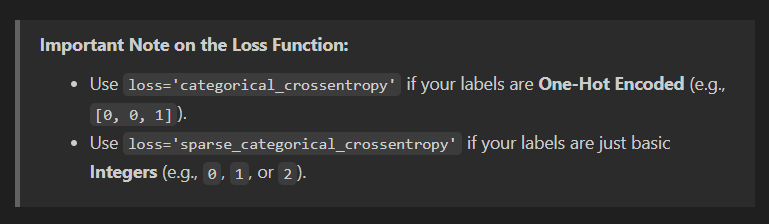

| Loss Function | Activation | Output / Model | Use Case |
| :--- | :--- | :--- | :--- |
| Hinge Loss | Step | Perceptron | Binary Classifier (-1, 1) |
| Log-Loss (Binary Cross Entropy) | Sigmoid | Logistic Regression | Binary Classifier (0, 1) |
| Categorical Cross Entropy | Softmax | Softmax Regression | Multiclass Classifier |
| **Mean Squared Error (MSE)** | **Linear (None)** | **Linear Regression** | **Continuous Regression** |
| **Mean Absolute Error (MAE)** | **Linear (None)** | **Robust Regression** | **Regression (Less sensitive to outliers)** |
| **Hinge Loss** | **Linear** | **Linear SVM** | **Binary Classifier (Maximum Margin)** |
| **Huber Loss** | **Linear** | **Robust Regression** | **Regression (Hybrid of MSE and MAE)** |
| **Binary Cross Entropy** | **ReLU / Tanh** | **Deep Neural Networks** | **Hidden Layers / Complex Feature Mapping** |
